对恒生指数期货进行回测

### 读取数据库数据

In [37]:
from sysdata.sim.db_futures_sim_data import dbFuturesSimData
data=dbFuturesSimData()
data


dbFuturesSimData object with 16 instruments

### 看看有什么工具

In [38]:
data.get_instrument_list()

['CHFJPY',
 'SP500_micro',
 'US20',
 'CORN',
 'FTSECHINAA',
 'V2X',
 'FTSECHINAH',
 'NASDAQ',
 'GOLD',
 'SP500',
 'BITCOIN',
 'HANGTECH',
 'SOFR',
 'EUROSTX',
 'US10',
 'HANG']

In [39]:
data.get_instrument_meta_data("HANG")

futuresInstrumentWithMetaData(instrument=HANG, meta_data={'Description': 'Hong Kong equity index Hang Seng', 'Pointsize': np.float64(50.0), 'Currency': 'HKD', 'AssetClass': 'Equity', 'PerBlock': np.float64(30.0), 'Percentage': np.float64(0.0), 'PerTrade': np.int64(0), 'Region': 'ASIA'})

In [40]:
data.get_raw_price("HANG").tail(10)

index
2025-03-28 15:00:00    23311.0
2025-03-28 16:00:00    23276.0
2025-03-28 17:00:00    23265.0
2025-03-28 18:00:00    23284.0
2025-03-31 01:00:00    23284.0
2025-03-31 02:00:00    23284.0
2025-03-31 03:00:00    23284.0
2025-03-31 05:00:00    23284.0
2025-03-31 06:00:00    23284.0
2025-03-31 07:00:00    23284.0
Name: price, dtype: float64

In [41]:
data.keys()
data['HANGTECH']

index
2020-12-21 02:00:00    8619.0
2020-12-21 03:00:00    8612.0
2020-12-21 05:00:00    8599.0
2020-12-21 06:00:00    8579.0
2020-12-21 07:00:00    8546.0
                        ...  
2025-04-01 14:00:00    5439.0
2025-04-01 15:00:00    5439.0
2025-04-01 16:00:00    5439.0
2025-04-01 17:00:00    5439.0
2025-04-01 18:00:00    5439.0
Name: price, Length: 17935, dtype: float64

In [42]:
data.get_instrument_raw_carry_data("HANG")


,PRICE,CARRY,PRICE_CONTRACT,CARRY_CONTRACT
index,,,,
2001-09-24 05:00:00,9270.0,NaN,20011000,20011100
2001-09-25 05:00:00,9169.0,NaN,20011000,20011100
2001-09-26 05:00:00,9339.0,NaN,20011000,20011100
2001-09-27 05:00:00,9580.0,NaN,20011000,20011100
2001-09-28 05:00:00,9975.0,9969.0,20011000,20011100
...,...,...,...,...
2025-03-31 02:00:00,NaN,23136.0,20250400,20250500
2025-03-31 03:00:00,NaN,22995.0,20250400,20250500
2025-03-31 05:00:00,23284.0,23340.0,20250400,20250500


In [43]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc

def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds Lfast, Lslow and vol_lookback

    """
    ## price: This is the stitched price series
    ## We can't use the price of the contract we're trading, or the volatility will be jumpy
    ## And we'll miss out on the rolldown. See https://qoppac.blogspot.com/2015/05/systems-building-futures-rolling.html

    price = price.resample("1B").last()
    if Lslow is None:
        Lslow = 4 * Lfast

    ## We don't need to calculate the decay parameter, just use the span directly

    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma

    vol = robust_vol_calc(price.diff())

    return raw_ewmac / vol

In [44]:
data.db_fx_prices_data.get_fx_prices('HKDUSD')

index
1991-03-06    0.128336
1991-03-07    0.128336
1991-03-08    0.128336
1991-03-11    0.128336
1991-03-12    0.128336
                ...   
2025-03-24    0.128600
2025-03-25    0.128600
2025-03-26    0.128600
2025-03-27    0.128600
2025-03-28    0.128600
Name: price, Length: 8856, dtype: float64

In [45]:
from sysdata.csv.csv_spot_fx import csvFxPricesData
csv_fx_prices = csvFxPricesData()
list_of_ccy_codes = csv_fx_prices.get_list_of_fxcodes()

db_fx_price_data = data.db_fx_prices_data

for currency_code in list_of_ccy_codes:
    fx_prices = csv_fx_prices.get_fx_prices(currency_code)
    print(currency_code)
    db_fx_price_data.add_fx_prices(
        code=currency_code, fx_price_data=fx_prices, ignore_duplication=True
    )

SGDUSD
2025-04-07 20:09:08 DEBUG dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'SGDUSD'} Wrote 9400 lines of prices for SGDUSD to parquetFxPricesData
2025-04-07 20:09:08 INFO dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'SGDUSD'} Added fx data for code SGDUSD
HKDUSD
2025-04-07 20:09:08 DEBUG dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'HKDUSD'} Wrote 8856 lines of prices for HKDUSD to parquetFxPricesData
2025-04-07 20:09:08 INFO dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'HKDUSD'} Added fx data for code HKDUSD
EURUSD
2025-04-07 20:09:08 DEBUG dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'EURUSD'} Wrote 6377 lines of prices for EURUSD to parquetFxPricesData
2025-04-07 20:09:08 INFO dbFuturesSimData {'component': 'parquetFxPricesData', 'currency_code': 'EURUSD'} Added fx data for code EURUSD
CADUSD
2025-04-07 20:09:08 DEBUG dbFuturesSimData {'component': 'pa

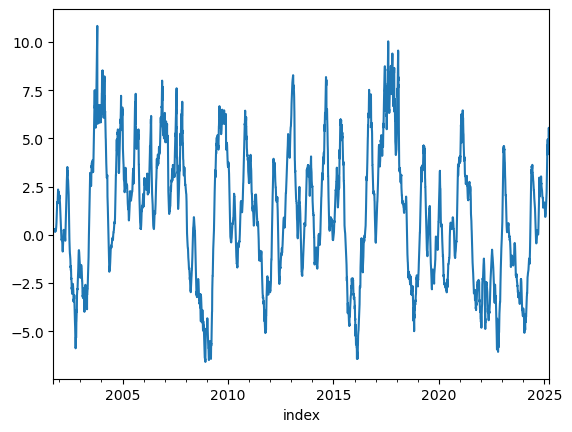

In [46]:
instrument_code='HANG'
price=data.daily_prices(instrument_code)
ewmac=calc_ewmac_forecast(price, 32, 128)
ewmac.tail(5)

from matplotlib.pyplot import show
ewmac.plot()
show()

In [47]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast = ewmac, price=price)
account.percent.stats()

[[('min', '-5.643'),
  ('max', '3.813'),
  ('median', '0'),
  ('mean', '0.004257'),
  ('std', '0.3986'),
  ('skew', '-0.7037'),
  ('ann_mean', '1.09'),
  ('ann_std', '6.378'),
  ('sharpe', '0.1709'),
  ('sortino', '0.1955'),
  ('avg_drawdown', '-8.716'),
  ('time_in_drawdown', '0.9827'),
  ('calmar', '0.05766'),
  ('avg_return_to_drawdown', '0.125'),
  ('avg_loss', '-0.2493'),
  ('avg_gain', '0.2435'),
  ('gaintolossratio', '0.9771'),
  ('profitfactor', '1.037'),
  ('hitrate', '0.5149'),
  ('t_stat', '0.8366'),
  ('p_value', '0.4029')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

annual mean for gross returns 1.089882385933933


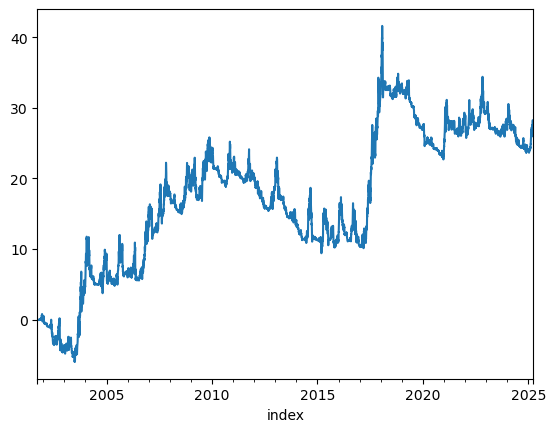

In [48]:
import syscore.pandas.strategy_functions

account.sharpe()  ## get the Sharpe Ratio (annualised), and any other statistic which is in the stats list
account.curve().plot()  ## plot the cumulative account curve (equivalent to account.cumsum().plot() inicidentally)
account.percent  ## gives a % curve
#syscore.pandas.strategy_functions.drawdown().plot()  ## see the drawdowns as a percentage
account.weekly  ## weekly returns (also daily [default], monthly, annual)
print("annual mean for gross returns",account.gross.ann_mean())  ## annual mean for gross returns, also costs (there are none in this simple example)

In [49]:
from systems.provided.rules.ewmac import ewmac_forecast_with_defaults as ewmac
from systems.forecasting import Rules
my_rules = Rules(dict(ewmac=ewmac))
my_rules.trading_rules()

{'ewmac': TradingRule; function: <function ewmac_forecast_with_defaults at 0x162006f20>, data: data.daily_prices (args: {}) and other_args: }

In [50]:

from systems.trading_rules import TradingRule

ewmac_rule = TradingRule(ewmac)
my_rules = Rules(dict(ewmac=ewmac_rule))
ewmac_rule

TradingRule; function: <function ewmac_forecast_with_defaults at 0x162006f20>, data: data.daily_prices (args: {}) and other_args: 

In [51]:
from systems.basesystem import System
from systems.trading_rules import TradingRule

ewmac_8 = TradingRule(ewmac, [], dict(Lfast=8, Lslow=32))
ewmac_32 = TradingRule(ewmac, [], dict(Lfast=32, Lslow=128))
my_rules = Rules(dict(ewmac8=ewmac_8, ewmac32=ewmac_32))
my_rules.trading_rules()['ewmac32']

my_system = System([my_rules], data)
my_system.rules.get_raw_forecast("HANG", "ewmac32").tail(5)
# my_system.rules.get_raw_forecast("HANG", "ewmac").tail(5)

2025-04-07 20:09:08 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-04-07 20:09:08 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:08 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-04-07 20:09:08 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-04-07 20:09:08 DEBUG base_system {'stage': 'rules', 'instrument_code': 'HANG'} Calculating raw forecast HANG for ewmac32


index
2025-03-25    1.403183
2025-03-26    1.426178
2025-03-27    1.453798
2025-03-28    1.471522
2025-03-31    1.489515
Freq: B, Name: price, dtype: float64

In [52]:
from sysdata.config.configdata import Config
my_config=Config()
my_config

Config with elements: 

In [53]:
empty_rules=Rules()
my_config.trading_rules=dict(ewmac8=ewmac_8, ewmac32=ewmac_32)
my_system=System([empty_rules], data, my_config)
print(my_system.rules.get_raw_forecast("HANG", "ewmac8"))

2025-04-07 20:09:08 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-04-07 20:09:08 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:08 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-04-07 20:09:08 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-04-07 20:09:08 DEBUG base_system {'stage': 'rules', 'instrument_code': 'HANG'} Calculating raw forecast HANG for ewmac8
index
2001-09-24         NaN
2001-09-25         NaN
2001-09-26         NaN
2001-09-27         NaN
2001-09-28         NaN
                ...   
2025-03-25    0.464986
2025-03-26    0.395686
2025-03-27    0.377161
2025-03-28    0.298036
2025-03-31    0.234839
Freq: B, Name: price, Length: 6136, dtype: float64


In [54]:
from systems.forecast_scale_cap import ForecastScaleCap


## By default we pool estimates across instruments. It's worth telling the system what instruments we want to use:
#
my_config.instruments=["HANG", "US10", "CORN", "SP500", "HANGTECH", "GOLD"]

## this parameter ensures we estimate:
my_config.use_forecast_scale_estimates=True

fcs=ForecastScaleCap()
my_system = System([fcs, my_rules], data, my_config)
print(my_system.forecastScaleCap.get_forecast_scalar("GOLD", "ewmac32").tail(5))

2025-04-07 20:09:08 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-04-07 20:09:08 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:08 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-04-07 20:09:08 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-04-07 20:09:08 DEBUG base_system {'stage': 'forecastScaleCap'} Getting cross sectional forecasts for scalar calculation for ewmac32 over CORN, GOLD, HANG, HANGTECH, SP500, US10
2025-04-07 20:09:08 DEBUG base_system {'stage': 'rules', 'instrument_code': 'CORN'} Calculating raw forecast CORN for ewmac32
2025-04-07 20:09:09 DEBUG base_system {'stage': 'rules', 'instrument_code': 'GOLD'} Calculating raw forecast GOLD for ewmac32
2025-04-07 20:09:09 DEBUG base_system {'stage': 'rules', 'instrument_code': 'HANG'} Calculating raw forec

In [55]:
my_config.forecast_scalars=dict(ewmac8=5.3, ewmac32=2.65)

## this parameter ensures we don't estimate:
my_config.use_forecast_scale_estimates=False

my_system=System([fcs, empty_rules], data, my_config)

print(my_system.forecastScaleCap.get_forecast_scalar("HANG", "ewmac32"))
2.65 # now a single float value

my_system.forecastScaleCap.get_capped_forecast("HANG", "ewmac32")

2025-04-07 20:09:09 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-04-07 20:09:09 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:09 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-04-07 20:09:09 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-04-07 20:09:09 DEBUG base_system {'stage': 'rules', 'instrument_code': 'HANG'} Calculating raw forecast HANG for ewmac32
index
2001-09-24    2.65
2001-09-25    2.65
2001-09-26    2.65
2001-09-27    2.65
2001-09-28    2.65
              ... 
2025-03-25    2.65
2025-03-26    2.65
2025-03-27    2.65
2025-03-28    2.65
2025-03-31    2.65
Freq: B, Length: 6136, dtype: float64
2025-04-07 20:09:09 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'HANG'} Calculating capped forecast for HANG ewmac32


index
2001-09-24         NaN
2001-09-25         NaN
2001-09-26         NaN
2001-09-27         NaN
2001-09-28         NaN
                ...   
2025-03-25    3.718434
2025-03-26    3.779372
2025-03-27    3.852564
2025-03-28    3.899533
2025-03-31    3.947215
Freq: B, Length: 6136, dtype: float64

In [56]:
from systems.forecast_combine import ForecastCombine

combiner = ForecastCombine()
my_system = System([fcs, empty_rules, combiner], data, my_config)
my_system.combForecast.get_forecast_weights("US10").tail(5)
my_system.combForecast.get_forecast_diversification_multiplier("US10").tail(5)


2025-04-07 20:09:09 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-04-07 20:09:09 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:09 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-04-07 20:09:09 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-04-07 20:09:09 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'US10'} Calculating forecast weights for US10
2025-04-07 20:09:09 WARNING base_system {'stage': 'combForecast', 'instrument_code': 'US10'} WARNING: No forecast weights  - using equal weights of 0.500 over all 2 trading rules in system
2025-04-07 20:09:09 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'US10'} Calculating capped forecast for US10 ewmac32
2025-04-07 20:09:09 DEBUG base_system {'stage': 'rules', 'instrument_code': 'US10

/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month


index
2024-12-13    1.0
2024-12-16    1.0
2024-12-17    1.0
2024-12-18    1.0
2024-12-19    1.0
Freq: B, dtype: float64

In [57]:
from systems.rawdata import RawData
from systems.positionsizing import PositionSizing
from systems.accounts.accounts_stage import Account
combiner = ForecastCombine()
raw_data = RawData()
position_size = PositionSizing()
my_account = Account()

## let's use naive markowitz to get more interesting results...
my_config.forecast_weight_estimate = dict(method="one_period")
my_config.use_forecast_weight_estimates = True
my_config.use_forecast_div_mult_estimates = True

combiner = ForecastCombine()
my_system = System([my_account, fcs, my_rules, combiner, position_size, raw_data], data, my_config)

print(my_system.combForecast.get_forecast_weights("GOLD").tail(5))
print(my_system.combForecast.get_forecast_diversification_multiplier("US10").tail(5))


2025-04-07 20:09:09 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-04-07 20:09:09 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:09 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-04-07 20:09:09 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-04-07 20:09:09 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'GOLD'} Calculating forecast weights for GOLD
2025-04-07 20:09:09 INFO base_system {'stage': 'combForecast', 'instrument_code': 'GOLD'} Calculating raw forecast weights for GOLD
2025-04-07 20:09:09 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'CORN'} Calculating capped forecast for CORN ewmac32
2025-04-07 20:09:09 DEBUG base_system {'stage': 'rules', 'instrument_code': 'CORN'} Calculating raw forecast CORN for ewmac32
2025-04-07 2

**任意指定固定的预测权重和多样化乘数**

In [58]:

my_config.forecast_weights=dict(ewmac8=0.5, ewmac32=0.5)
my_config.forecast_div_multiplier=1.1
my_config.use_forecast_weight_estimates = False
my_config.use_forecast_div_mult_estimates = False
my_system=System([fcs, empty_rules, combiner, raw_data, position_size], data, my_config)
my_system.combForecast.get_combined_forecast("HANG").tail(5)



2025-04-07 20:09:11 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-04-07 20:09:11 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:11 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-04-07 20:09:11 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-04-07 20:09:11 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'HANG'} Calculating combined forecast for HANG
2025-04-07 20:09:11 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'HANG'} Calculating capped forecast for HANG ewmac32
2025-04-07 20:09:11 DEBUG base_system {'stage': 'rules', 'instrument_code': 'HANG'} Calculating raw forecast HANG for ewmac32
2025-04-07 20:09:11 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'HANG'} Calculating capped forecast for HANG ewmac8
2025

/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month


index
2025-03-25    3.400573
2025-03-26    3.232080
2025-03-27    3.218334
2025-03-28    3.013517
2025-03-31    2.855523
Freq: B, dtype: float64

**设定风险目标和资本金**

In [59]:

my_config.percentage_vol_target=25
my_config.notional_trading_capital=100000
my_config.base_currency="USD"

my_system=System([ fcs, empty_rules, combiner, position_size, raw_data], data, my_config)

my_system.positionSize.get_subsystem_position("HANG").tail(5)
#my_system.combForecast.get_combined_forecast("US10").tail(5)
#my_system.combForecast.get_combined_forecast("SP500").tail(5)

2025-04-07 20:09:11 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-04-07 20:09:11 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:11 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-04-07 20:09:11 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-04-07 20:09:11 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANG'} Calculating subsystem position for HANG
2025-04-07 20:09:11 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANG'} Calculating volatility scalar for HANG
2025-04-07 20:09:11 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANG'} Calculating instrument value vol for HANG
2025-04-07 20:09:11 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANG'} Calculating instrument currency vol for HANG
2025-04-0

/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month


index
2025-03-25    0.227207
2025-03-26    0.220346
2025-03-27    0.220833
2025-03-28    0.201598
2025-03-31    0.195141
Freq: B, dtype: float64

In [60]:
my_config.instruments

['HANG', 'US10', 'CORN', 'SP500', 'HANGTECH', 'GOLD']

In [62]:
my_config.instrument_weights=dict(US10=.1, HANG=.4, CORN=.3, SP500=.8, HANGTECH=.5, GOLD=.2)
my_config.instrument_div_multiplier=1.5
my_config.use_instrument_weight_estimates = False
my_config.use_instrument_div_mult_estimates = False

my_system=System([ fcs, empty_rules, combiner, position_size, raw_data, portfolio], data, my_config)

my_system.portfolio.get_notional_position("US10").tail(5)

2025-04-07 20:09:13 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-04-07 20:09:13 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:13 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-04-07 20:09:13 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-04-07 20:09:13 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'US10'} Calculating notional position for US10
2025-04-07 20:09:13 INFO base_system {'stage': 'portfolio', 'instrument_code': 'US10'} Calculating instrument weights
2025-04-07 20:09:13 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'US10'} Calculating raw instrument weights
2025-04-07 20:09:13 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:13 DEBUG base_system Following instrum

/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month
/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month
/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month


2025-04-07 20:09:13 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'HANG'} Using fixed FDM multiplier of 1.100 for HANG
2025-04-07 20:09:13 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'HANG'} No mapping applied for HANG
2025-04-07 20:09:13 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANGTECH'} Calculating subsystem position for HANGTECH
2025-04-07 20:09:13 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANGTECH'} Calculating volatility scalar for HANGTECH
2025-04-07 20:09:13 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANGTECH'} Calculating instrument value vol for HANGTECH
2025-04-07 20:09:13 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANGTECH'} Calculating instrument currency vol for HANGTECH
2025-04-07 20:09:13 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'HANGTECH'} Calculating daily volatility for HANGTECH
2025-04-07 20:09:13 DEBUG base_system {'stage': 'ra

/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month
/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month
/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month


index
2024-12-13    0.165127
2024-12-16    0.168273
2024-12-17    0.171468
2024-12-18    0.174714
2024-12-19    0.178010
Freq: B, dtype: float64

In [63]:
from systems.accounts.accounts_stage import Account
accounts=Account()
my_system=System([ fcs, empty_rules, combiner, position_size, raw_data, portfolio, accounts], data, my_config)
profits=my_system.accounts.portfolio()
profits.percent.stats()

2025-04-07 20:09:13 DEBUG config {'type': 'config', 'stage': 'config'} Adding config defaults
2025-04-07 20:09:13 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2025-04-07 20:09:13 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2025-04-07 20:09:13 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2025-04-07 20:09:13 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2025-04-07 20:09:13 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2025-04-07 20:09:13 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2025-04-07 20:09:13 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating notional position for CORN
2025-04-07 20:09:13 INFO base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating instrument

/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month
/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month
/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month


2025-04-07 20:09:14 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'HANG'} Using fixed FDM multiplier of 1.100 for HANG
2025-04-07 20:09:14 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'HANG'} No mapping applied for HANG
2025-04-07 20:09:14 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANGTECH'} Calculating subsystem position for HANGTECH
2025-04-07 20:09:14 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANGTECH'} Calculating volatility scalar for HANGTECH
2025-04-07 20:09:14 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANGTECH'} Calculating instrument value vol for HANGTECH
2025-04-07 20:09:14 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'HANGTECH'} Calculating instrument currency vol for HANGTECH
2025-04-07 20:09:14 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'HANGTECH'} Calculating daily volatility for HANGTECH
2025-04-07 20:09:14 DEBUG base_system {'stage': 'ra

/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month
/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month
/Users/henrik/dev/pysystemtrade/syscore/pandas/frequency.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_index = list(df.resample("1M").last().index)  ## last day in month


2025-04-07 20:09:14 INFO base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Using fixed diversification multiplier 1.500000
2025-04-07 20:09:14 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} No risk overlay in config: won't apply risk scaling
2025-04-07 20:09:14 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating buffers for CORN
2025-04-07 20:09:14 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating forecast method buffers for CORN
2025-04-07 20:09:14 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating buffered positions
2025-04-07 20:09:14 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2025-04-07 20:09:14 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'CORN'} Calculating daily prices for CORN
2025-04-07 20:09:14 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'GOLD'} Calculating pandl for

/Users/henrik/miniconda3/envs/invest/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1127: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean
/Users/henrik/miniconda3/envs/invest/lib/python3.13/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/Users/henrik/dev/pysystemtrade/systems/accounts/curves/account_curve.py:261: RuntimeWarning: invalid value encountered in scalar divide
  return self.ann_mean() / -self.worst_drawdown()
/Users/henrik/dev/pysystemtrade/systems/accounts/curves/account_curve.py:264: RuntimeWarning: invalid value encountered in scalar divide
  return self.ann_mean() / -self.avg_drawdown()


[[('min', '-inf'),
  ('max', '2.793'),
  ('median', '0'),
  ('mean', '-inf'),
  ('std', 'nan'),
  ('skew', 'nan'),
  ('ann_mean', '-inf'),
  ('ann_std', 'nan'),
  ('sharpe', 'nan'),
  ('sortino', 'nan'),
  ('avg_drawdown', '-inf'),
  ('time_in_drawdown', '0.9642'),
  ('calmar', 'nan'),
  ('avg_return_to_drawdown', 'nan'),
  ('avg_loss', '-inf'),
  ('avg_gain', '0.3983'),
  ('gaintolossratio', '0'),
  ('profitfactor', '0'),
  ('hitrate', '0.4791'),
  ('t_stat', 'nan'),
  ('p_value', 'nan')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]